In [275]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import time
import os
from scipy.optimize import curve_fit
import B00_codes.dataReader as dr
from mpl_toolkits.axes_grid1 import make_axes_locatable
import math
import matplotlib.colors as mcolors
import json
from scipy.special import jn
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
from lmfit import Model, Parameters, minimize
from scipy.integrate import dblquad
from matplotlib.colors import to_rgba
%matplotlib inline
pi = np.pi

In [276]:
def noise_kernel_time(ti, tj, tau_c):
    return np.exp(-((ti - tj) ** 2) / (2 * tau_c ** 2))

def dyn_step_single(s0_vec, h0_vec, delta_t):
    """
    Result of evolution in a static magnetic field h0_vec
    for time delta_t starting from s0_vec.
    """
    h0 = np.linalg.norm(h0_vec)
    if h0 != 0:
        chi = np.dot(s0_vec, h0_vec) / h0
        s_vec = (np.cos(h0 * delta_t) * s0_vec +
                 chi * (1 - np.cos(h0 * delta_t)) * h0_vec / h0 +
                 np.sin(h0 * delta_t) * np.cross(h0_vec / h0, s0_vec))
    else:
        s_vec = s0_vec
    return s_vec

def single_traj(time_grid, delta_t, C, amp, delta, G_t=None):
    Ntime=len(time_grid)
    if G_t is None:
        G_t = np.random.multivariate_normal(np.zeros(Ntime), C)
    hx_t = np.real(G_t * (amp + np.conjugate(amp)))
    hy_t = np.real(G_t * 1j * (amp - np.conjugate(amp)))
    hz_t = delta * np.ones_like(G_t)

    sx_t = np.zeros(Ntime)
    sy_t = np.zeros(Ntime)
    sz_t = np.zeros(Ntime)
    sz_t[0] = 1

    for idx in range(Ntime - 1):
        h0_vec = np.array([hx_t[idx], hy_t[idx], hz_t[idx]])
        s0_vec = np.array([sx_t[idx], sy_t[idx], sz_t[idx]])
        s_vec = dyn_step_single(s0_vec, h0_vec, delta_t)

        [sx_t[idx + 1], sy_t[idx + 1], sz_t[idx + 1]] = s_vec

    return sx_t, sy_t, sz_t, G_t

# Function to compute Bloch sphere coordinates
def bloch_coordinates(theta, phi):
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    return x, y, z

# Function to create a Bloch sphere in a given axis
def plot_bloch_sphere(ax):
    ax.set_box_aspect([1, 1, 1])
    ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1]); ax.set_zlim([-1, 1])
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')

    # Hide tick labels
    ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])

    # Generate Bloch sphere mesh
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones(np.size(u)), np.cos(v))

    # Plot the Bloch sphere
    ax.plot_surface(x, y, z, color='b', alpha=0.05)

    ax.grid(False)  # Disable grid lines
    ax.xaxis.pane.fill = False  # Remove background panes
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    # Remove 3D bounding box
    ax.xaxis.pane.set_edgecolor('none')
    ax.yaxis.pane.set_edgecolor('none')
    ax.zaxis.pane.set_edgecolor('none')


# No detuning

In [277]:
np.random.seed(3) # Fixed seed for reproducibility
# T1 process, ensemble avg over many trajectories
Tmax = 10 ; delta_t = 0.025; tau_c = 0.01 # noise correlation time
delta_t = np.sqrt(2 * np.pi) * tau_c
time_grid = np.arange(0, Tmax + delta_t, delta_t); Ntime = len(time_grid)

# Cumulative amplitude
phi = -pi/2; amp = 3 * np.exp(1j*phi)  # amp_1 = A_1 * gamma * np.sin(theta_1) * 1j * np.exp(-1j * phi_1) / 4
Num_traj = 500; delta1 = 0; delta2 = 0 # detuning

sx_avg, sy_avg, sz_avg = np.zeros(Ntime), np.zeros(Ntime), np.zeros(Ntime)
sxs, sys, szs, Gs = np.zeros((Num_traj, Ntime)), np.zeros((Num_traj, Ntime)), np.zeros((Num_traj, Ntime)), np.zeros((Num_traj, Ntime))
sx_avg2, sy_avg2, sz_avg2 = np.zeros(Ntime), np.zeros(Ntime), np.zeros(Ntime)
sxs2, sys2, szs2 = np.zeros((Num_traj, Ntime)), np.zeros((Num_traj, Ntime)), np.zeros((Num_traj, Ntime))

# The covariance matrix
C = np.array([[noise_kernel_time(ti, tj, tau_c) for tj in time_grid] for ti in time_grid])

for i in np.arange(Num_traj):
    sx_t, sy_t, sz_t, G_t = single_traj(time_grid, delta_t, C, amp, delta1)
    sx_avg += sx_t; sy_avg += sy_t; sz_avg += sz_t
    sxs[i], sys[i], szs[i], Gs[i] = sx_t, sy_t, sz_t, G_t

    sx_t2, sy_t2, sz_t2,_ = single_traj(time_grid, delta_t, C, amp, delta2, G_t)
    sx_avg2 += sx_t2; sy_avg2 += sy_t2; sz_avg2 += sz_t2
    sxs2[i], sys2[i], szs2[i] = sx_t2, sy_t2, sz_t2

sx_avg = sx_avg / Num_traj; sy_avg = sy_avg / Num_traj; sz_avg = sz_avg / Num_traj
sx_avg2 = sx_avg2 / Num_traj; sy_avg2 = sy_avg2 / Num_traj; sz_avg2 = sz_avg2 / Num_traj
    

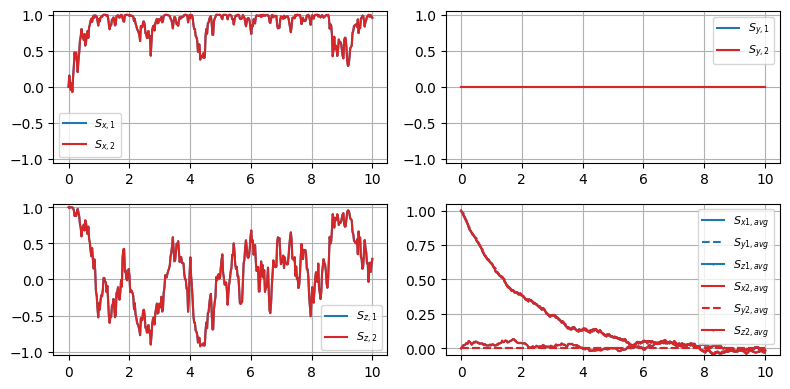

In [278]:
fig,axs = plt.subplots(2,2,figsize=(8,4)); fs=8; iter=20; t = time_grid
axs[0,0].plot(t, sxs[iter], label='$S_{x,1}$', color='C0')
axs[0,0].plot(t, sxs2[iter], label='$S_{x,2}$', color='C3')
axs[0,1].plot(t, sys[iter], label='$S_{y,1}$', color='C0')
axs[0,1].plot(t, sys2[iter], label='$S_{y,2}$', color='C3')
axs[1,0].plot(t, szs[iter], label='$S_{z,1}$', color='C0')
axs[1,0].plot(t, szs2[iter], label='$S_{z,2}$', color='C3')

axs[1,1].plot(t, sx_avg, '-', label='$S_{x1,avg}$',color='C0')
axs[1,1].plot(t, sy_avg, '--', label='$S_{y1,avg}$',color='C0')
axs[1,1].plot(t, sz_avg, '.-', label='$S_{z1,avg}$',color='C0',markersize=1)
axs[1,1].plot(t, sx_avg2, '-', label='$S_{x2,avg}$',color='C3')
axs[1,1].plot(t, sy_avg2, '--', label='$S_{y2,avg}$',color='C3')
axs[1,1].plot(t, sz_avg2, '.-', label='$S_{z2,avg}$',color='C3',markersize=1)

# axs[0,0].vlines(x=7.15,ymin=-1,ymax=1,linewidth=0.5)

for i in range(2):
    for j in range(2):
        axs[i,j].grid(True)
        axs[i,j].legend(fontsize=fs)
        axs[i,j].set_ylim((-1.05,1.05))
axs[1,1].set_ylim(-0.05,1.05)
plt.tight_layout()

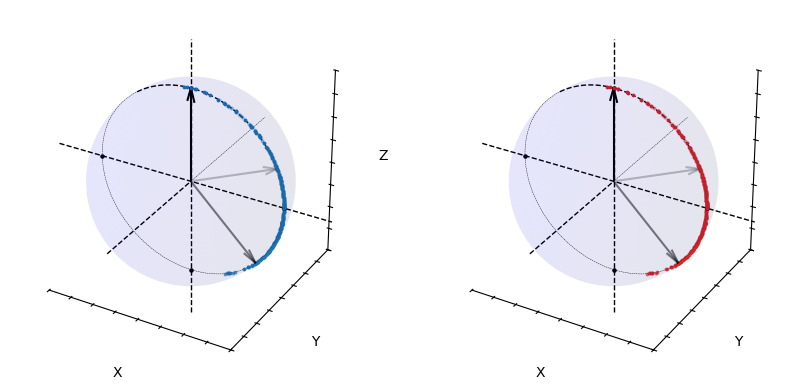

In [279]:
fig, axs = plt.subplots(1, 2, figsize=(10,10), subplot_kw={'projection': '3d'})
alphas = np.linspace(1, 0.05, Ntime)

for i in range(2):
    # Plot the Bloch vectors (arrows)
    plot_bloch_sphere(axs[i])

    # Plot the coordinate axes
    axs[i].plot([0, 0], [0, 0], [-1.5, 1.5], color='k', linestyle='--', linewidth=1)
    axs[i].plot([-1.5, 1.5], [0, 0], [0, 0], color='k', linestyle='--', linewidth=1)
    axs[i].plot([0, 0], [-1.5, 0], [0, 0], color='k', linestyle='--', linewidth=1)
    axs[i].plot([0, 0], [0, 1.5], [0, 0], color='k', linestyle='--', linewidth=0.3)

    # Add a cross-sectional circle in the XZ plane
    th = np.linspace(-0.2*pi, 0.75*pi, 96)
    x_circle = np.sin(th)
    y_circle = np.zeros_like(th) 
    z_circle = np.cos(th) 
    axs[i].plot(x_circle, y_circle, z_circle, color='k', linestyle='--', linewidth=1, label="XZ Cross-Section")
    th = np.linspace(0.75*pi, 1.8*pi, 106)
    x_circle = np.sin(th)
    y_circle = np.zeros_like(th) 
    z_circle = np.cos(th) 
    axs[i].plot(x_circle, y_circle, z_circle, color='k', linestyle='--', linewidth=0.3, label="XZ Cross-Section")

    # y_circle = np.sin(th)
    # x_circle = np.zeros_like(th)
    # axs[i].plot(x_circle, y_circle, z_circle, color='k', linestyle='--', linewidth=0.3, label="YZ Cross-Section")

    # Add black dots at the North Pole (0,0,1) and South Pole (0,0,-1)
    axs[i].scatter(0, 0, 1, color='k', s=5)   # North Pole
    axs[i].scatter(0, 0, -1, color='k', s=5)  # South Pole
    axs[i].scatter(1, 0, 0, color='k', s=5)  
    axs[i].scatter(-1, 0, 0, color='k', s=5)  
    # axs[i].scatter(0, 1, 0, color='k', s=5) 
    # axs[i].scatter(0,-1, 0, color='k', s=5) 

for iter in np.array([20]):
    for i, sz in enumerate(szs[iter]):
        if np.mod(i,1)==0:
            sx = sxs[iter,i]; sy = sys[iter,i]
            sx2 = sxs2[iter,i]; sy2 = sys2[iter,i]; sz2 = szs2[iter,i]

            # Compute color with fading alpha
            color = to_rgba('C0', alphas[i]); color2 = to_rgba('C3', alphas[i]); color3 = to_rgba('k', alphas[i])

            if i in np.array([0,180,310]):
                if i==180: color3 = to_rgba('k', alphas[210])
                if i==310: color3 = to_rgba('k', alphas[320])
                axs[0].quiver(0, 0, 0, sx, sy, sz, color=color3, linewidth=1.5, arrow_length_ratio=0.15) 
                axs[1].quiver(0, 0, 0, sx2, sy2, sz2, color=color3, linewidth=1.5, arrow_length_ratio=0.15)  
            axs[0].scatter(sx,sy,sz, color=color, s=3) 
            axs[1].scatter(sx2,sy2,sz2, color=color2, s=3) 

In [ ]:
# fig.savefig('C:/Users/lukin2dmaterials/data/forDeliv/figs/fig4_bloch2.svg', format='svg')

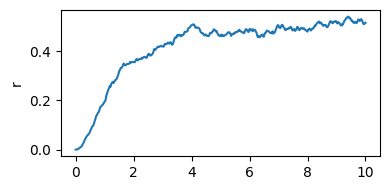

In [281]:
r = np.nanmean(szs*szs2,axis=0) - np.nanmean(szs,axis=0)*np.nanmean(szs2,axis=0)
fig,ax=plt.subplots(figsize=(4,2))
ax.plot(time_grid,r)
ax.set_ylabel('r')
plt.tight_layout()

# With detuning

In [282]:
# T1 process, ensemble avg over many trajectories
Tmax = 10 ; delta_t = 0.025; tau_c = 0.01 # noise correlation time
delta_t = np.sqrt(2 * np.pi) * tau_c
time_grid = np.arange(0, Tmax + delta_t, delta_t); Ntime = len(time_grid)

# Cumulative amplitude
phi = -pi/2; amp = 3 * np.exp(1j*phi)  # amp_1 = A_1 * gamma * np.sin(theta_1) * 1j * np.exp(-1j * phi_1) / 4
Num_traj = 500; delta1 = 0.14*2*pi; delta2 = 0 # detuning

sx_avg, sy_avg, sz_avg = np.zeros(Ntime), np.zeros(Ntime), np.zeros(Ntime)
sxs, sys, szs = np.zeros((Num_traj, Ntime)), np.zeros((Num_traj, Ntime)), np.zeros((Num_traj, Ntime))
sx_avg2, sy_avg2, sz_avg2 = np.zeros(Ntime), np.zeros(Ntime), np.zeros(Ntime)
sxs2, sys2, szs2 = np.zeros((Num_traj, Ntime)), np.zeros((Num_traj, Ntime)), np.zeros((Num_traj, Ntime))

# The covariance matrix
C = np.array([[noise_kernel_time(ti, tj, tau_c) for tj in time_grid] for ti in time_grid])

for i in np.arange(Num_traj):
    G_t = Gs[i]  #inherit G_t from 0-detuning for consistency
    sx_t, sy_t, sz_t, _ = single_traj(time_grid, delta_t, C, amp, delta1, G_t)
    sx_avg += sx_t; sy_avg += sy_t; sz_avg += sz_t
    sxs[i], sys[i], szs[i] = sx_t, sy_t, sz_t

    sx_t2, sy_t2, sz_t2,_ = single_traj(time_grid, delta_t, C, amp, delta2, G_t)
    sx_avg2 += sx_t2; sy_avg2 += sy_t2; sz_avg2 += sz_t2
    sxs2[i], sys2[i], szs2[i] = sx_t2, sy_t2, sz_t2

sx_avg = sx_avg / Num_traj; sy_avg = sy_avg / Num_traj; sz_avg = sz_avg / Num_traj
sx_avg2 = sx_avg2 / Num_traj; sy_avg2 = sy_avg2 / Num_traj; sz_avg2 = sz_avg2 / Num_traj
    

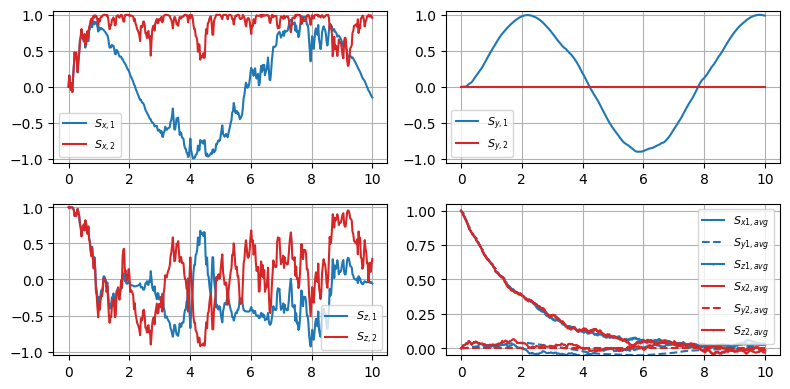

In [283]:
fig,axs = plt.subplots(2,2,figsize=(8,4)); fs=8; iter=20; t = time_grid
axs[0,0].plot(t, sxs[iter], label='$S_{x,1}$', color='C0')
axs[0,0].plot(t, sxs2[iter], label='$S_{x,2}$', color='C3')
axs[0,1].plot(t, sys[iter], label='$S_{y,1}$', color='C0')
axs[0,1].plot(t, sys2[iter], label='$S_{y,2}$', color='C3')
axs[1,0].plot(t, szs[iter], label='$S_{z,1}$', color='C0')
axs[1,0].plot(t, szs2[iter], label='$S_{z,2}$', color='C3')

axs[1,1].plot(t, sx_avg, '-', label='$S_{x1,avg}$',color='C0')
axs[1,1].plot(t, sy_avg, '--', label='$S_{y1,avg}$',color='C0')
axs[1,1].plot(t, sz_avg, '.-', label='$S_{z1,avg}$',color='C0',markersize=1)
axs[1,1].plot(t, sx_avg2, '-', label='$S_{x2,avg}$',color='C3')
axs[1,1].plot(t, sy_avg2, '--', label='$S_{y2,avg}$',color='C3')
axs[1,1].plot(t, sz_avg2, '.-', label='$S_{z2,avg}$',color='C3',markersize=1)

# ax.set_title('Time trajectory', fontsize=fs)
# ax.set_xlabel('Time (t)')
for i in range(2):
    for j in range(2):
        axs[i,j].grid(True)
        axs[i,j].legend(fontsize=fs)
        axs[i,j].set_ylim((-1.05,1.05))
axs[1,1].set_ylim(-0.05,1.05)
plt.tight_layout()

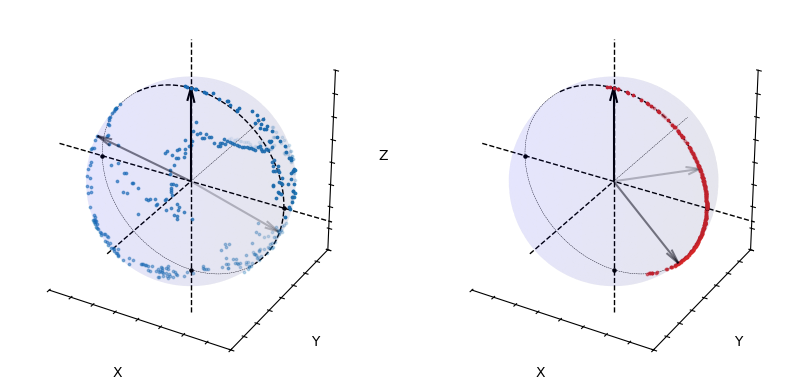

In [284]:
fig, axs = plt.subplots(1, 2, figsize=(10,10), subplot_kw={'projection': '3d'})
alphas = np.linspace(1, 0.05, Ntime)

for i in range(2):
    # Plot the Bloch vectors (arrows)
    plot_bloch_sphere(axs[i])

    # Plot the coordinate axes
    axs[i].plot([0, 0], [0, 0], [-1.5, 1.5], color='k', linestyle='--', linewidth=1)
    axs[i].plot([-1.5, 1.5], [0, 0], [0, 0], color='k', linestyle='--', linewidth=1)
    axs[i].plot([0, 0], [-1.5, 0], [0, 0], color='k', linestyle='--', linewidth=1)
    axs[i].plot([0, 0], [0, 1.5], [0, 0], color='k', linestyle='--', linewidth=0.3)

    # Add a cross-sectional circle in the XZ plane
    th = np.linspace(-0.2*pi, 0.75*pi, 96)
    x_circle = np.sin(th)
    y_circle = np.zeros_like(th) 
    z_circle = np.cos(th) 
    axs[i].plot(x_circle, y_circle, z_circle, color='k', linestyle='--', linewidth=1, label="XZ Cross-Section")
    th = np.linspace(0.75*pi, 1.8*pi, 106)
    x_circle = np.sin(th)
    y_circle = np.zeros_like(th) 
    z_circle = np.cos(th) 
    axs[i].plot(x_circle, y_circle, z_circle, color='k', linestyle='--', linewidth=0.3, label="XZ Cross-Section")

    # y_circle = np.sin(th)
    # x_circle = np.zeros_like(th)
    # axs[i].plot(x_circle, y_circle, z_circle, color='k', linestyle='--', linewidth=0.3, label="YZ Cross-Section")

    # Add black dots at the North Pole (0,0,1) and South Pole (0,0,-1)
    axs[i].scatter(0, 0, 1, color='k', s=5)   # North Pole
    axs[i].scatter(0, 0, -1, color='k', s=5)  # South Pole
    axs[i].scatter(1, 0, 0, color='k', s=5)  
    axs[i].scatter(-1, 0, 0, color='k', s=5)  
    # axs[i].scatter(0, 1, 0, color='k', s=5) 
    # axs[i].scatter(0,-1, 0, color='k', s=5) 

for iter in np.array([20]):
    for i, sz in enumerate(szs[iter]):
        if np.mod(i,1)==0:
            sx = sxs[iter,i]; sy = sys[iter,i]
            sx2 = sxs2[iter,i]; sy2 = sys2[iter,i]; sz2 = szs2[iter,i]

            # Compute color with fading alpha
            color = to_rgba('C0', alphas[i]); color2 = to_rgba('C3', alphas[i]); color3 = to_rgba('k', alphas[i])

            if i in np.array([0,180,310]):
                if i==180: color3 = to_rgba('k', alphas[210])
                if i==310: color3 = to_rgba('k', alphas[320])
                axs[0].quiver(0, 0, 0, sx, sy, sz, color=color3, linewidth=1.5, arrow_length_ratio=0.15) 
                axs[1].quiver(0, 0, 0, sx2, sy2, sz2, color=color3, linewidth=1.5, arrow_length_ratio=0.15)  
            axs[0].scatter(sx,sy,sz, color=color, s=3) 
            axs[1].scatter(sx2,sy2,sz2, color=color2, s=3) 

In [ ]:
# fig.savefig('C:/Users/lukin2dmaterials/data/forDeliv/figs/fig4_blochdet2.svg', format='svg')

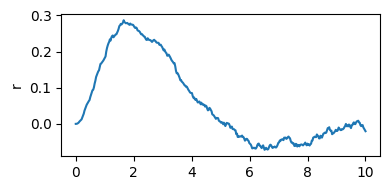

In [286]:
r = np.nanmean(szs*szs2,axis=0) - np.nanmean(szs,axis=0)*np.nanmean(szs2,axis=0)
fig,ax=plt.subplots(figsize=(4,2))
ax.plot(time_grid,r)
ax.set_ylabel('r')
# ax.set_xlim((-0.5,8.5))
plt.tight_layout()